# FIGS — Case Analysis & Display

Run (or load) a forecast for a HRRR cycle, render SPC-style probability /
categorical / median-intensity maps, and overlay the observed storm reports.

In [1]:
# Run with the `met` conda env kernel.
import warnings; warnings.filterwarnings('ignore')
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '..')   # so `import figs` works from notebooks/
from figs import config as C

In [2]:
from datetime import datetime, timezone, timedelta
from figs.model.predict import predict_forecast
from figs.products import plots, summary, cig, netcdf
from figs.data import reports, grid

# RUN   = datetime(2023, 4, 19, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2026, 6, 17, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
# RUN   = datetime(2026, 5, 18, 18, tzinfo=timezone.utc)  # HRRR cycle to forecast
RUN   = datetime(2026, 6, 18, 12, tzinfo=timezone.utc)  # HRRR cycle to forecast
FXX   = list(range(1, 19))                              # forecast hours
HAZARD = 'tor'                                          # 'tor' | 'wind' | 'hail'
MODELS = None                                           # None -> Data/models
DL_WORKERS = 8                                          # forecast hours downloaded concurrently

## Predict (or load a prepared netCDF)

In [3]:
try:
    preds = predict_forecast(RUN, FXX, models_dir=MODELS, max_members=6, workers=DL_WORKERS)
    print('predicted', len(preds), 'forecast hours')
except Exception as e:
    print('predict failed (need trained models?):', e)
    preds = None

✅ Found ┊ model=hrrr ┊ product=prs ┊ 2026-Jun-18 12:00 UTC F01 ┊ GRIB2 @ aws ┊ IDX @ local


/opt/miniconda3/envs/met/lib/python3.14/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


✅ Found ┊ model=hrrr ┊ product=prs ┊ 2026-Jun-18 12:00 UTC F02 ┊ GRIB2 @ aws ┊ IDX @ local


/opt/miniconda3/envs/met/lib/python3.14/site-packages/herbie/core.py:978: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  logic = df.search_this.str.contains(search)


✅ Found ┊ model=hrrr ┊ product=prs ┊ 2026-Jun-18 12:00 UTC F03 ┊ GRIB2 @ aws ┊ IDX @ local


...

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-18 12:00 UTC F18 ┊ GRIB2 @ aws ┊ IDX @ local


/opt/miniconda3/envs/met/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/met/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/en

Note: Returning a list of [12] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2026-Jun-18 12:00 UTC F18 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-17 12:00 UTC F42 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-18 06:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ✅ Found ┊ product=sfc ┊ 2026-Jun-17 06:00 UTC F48┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-17 18:00 UTC F36 ┊ GRIB2 @ aws ┊ IDX @ local
 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-18 00:00 UTC F30 ┊ GRIB2 @ aws ┊ IDX @ local
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with mult

/opt/miniconda3/envs/met/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/envs/met/lib/python3.14/site-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
/opt/miniconda3/en

Note: Returning a list of [12] xarray.Datasets because cfgrib opened with multiple hypercubes.
✅ Found ┊ model=hrrr ┊ product=prs ┊ 2026-Jun-18 12:00 UTC F17 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-17 12:00 UTC F41 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-18 06:00 UTC F23 ┊ GRIB2 @ aws ┊ IDX @ local
✅ Found✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-17 18:00 UTC F35 ┊ GRIB2 @ aws ┊ IDX @ local
 ✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-18 00:00 UTC F29┊ model=hrrr ┊ product=sfc  ┊ 2026-Jun-18 11:00 UTC F18┊ GRIB2 @ aws ┊ GRIB2 @ aws ┊ IDX @ local
 ┊ IDX @ local
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with multiple hypercubes.
Note: Returning a list of [3] xarray.Datasets because cfgrib opened with mult

## Map extent

Plan-view extent `[lon_min, lon_max, lat_min, lat_max]` for ALL plots below — kept
in its own cell AFTER predict so you can re-tune the zoom and re-run just the plots
without re-forecasting. `None` lets cartopy auto-fit the FIGS grid.

In [4]:
# MAP_EXTENT = [-110, -80, 25, 55]
MAP_EXTENT = [-95, -80, 25, 40] # Dixie
# MAP_EXTENT = [-105, -90, 30, 45] # Plains
plots.set_extent(MAP_EXTENT)

## Per-forecast-hour SPC-style probability map

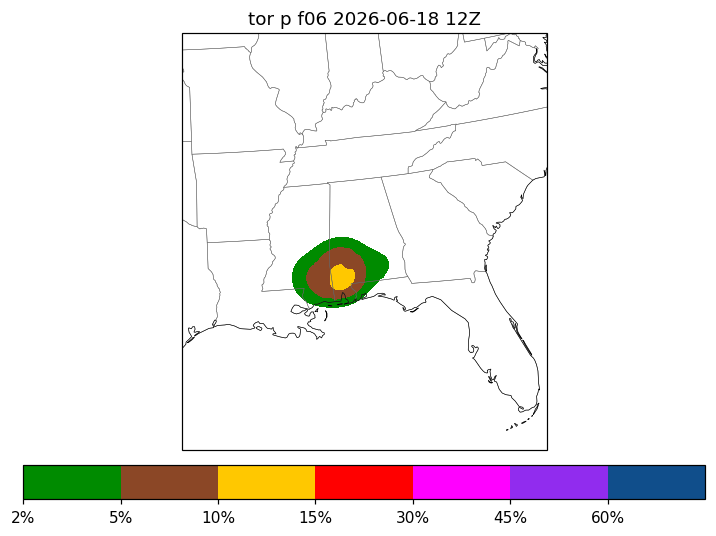

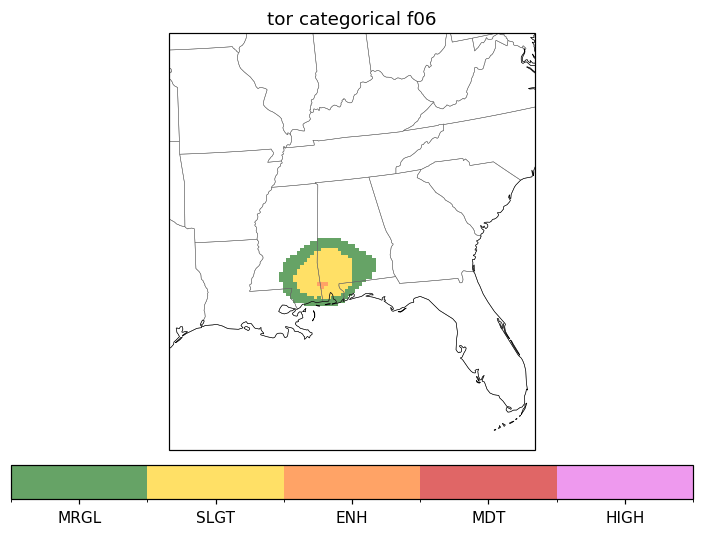

In [5]:
FH = 6  # forecast hour to display
if preds:
    p = preds[FH][f'p_{HAZARD}']
    dist = np.nan_to_num(preds[FH][f'dist_{HAZARD}'])
    risk = cig.categorical_risk(HAZARD, p*100, dist)
    plots.plot_probability(p, HAZARD, f'{HAZARD} p f{FH:02d} {RUN:%Y-%m-%d %HZ}', '/tmp/_p.png')
    plots.plot_categorical(risk['category'], HAZARD, f'{HAZARD} categorical f{FH:02d}', '/tmp/_c.png')
    from IPython.display import Image, display
    display(Image('/tmp/_p.png')); display(Image('/tmp/_c.png'))

## Day-total (cumulative) risk + median intensity

The cumulative daily **categorical** outlook is ALWAYS across all 3 hazards (the SPC Day-1 categorical = max category over tor/wind/hail). **Day-max** median conditional-intensity is shown for **each** hazard (per-hour median bin, maxed over hours), masked to that hazard's threat area (day-max prob ≥ its lowest SPC level).

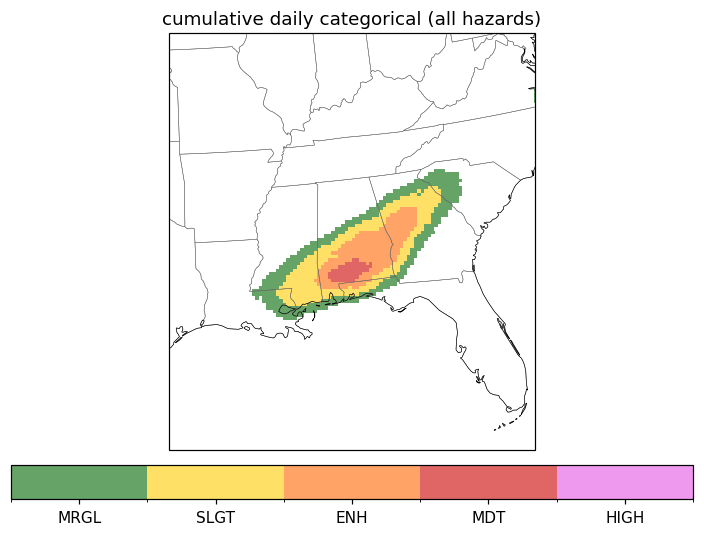

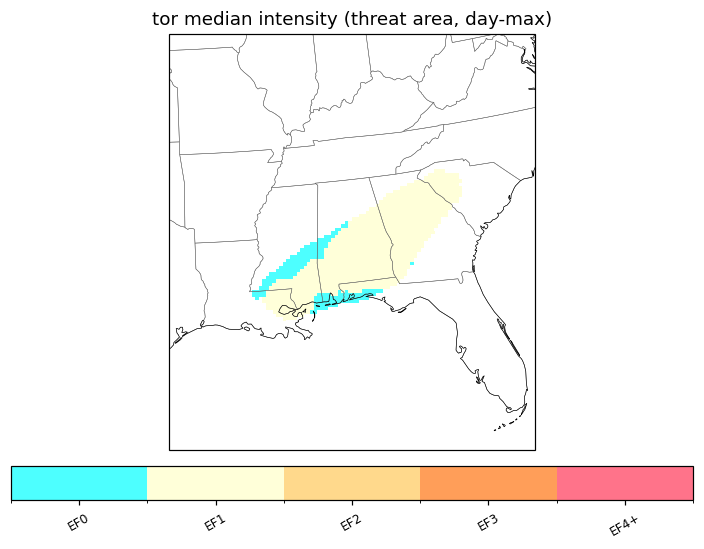

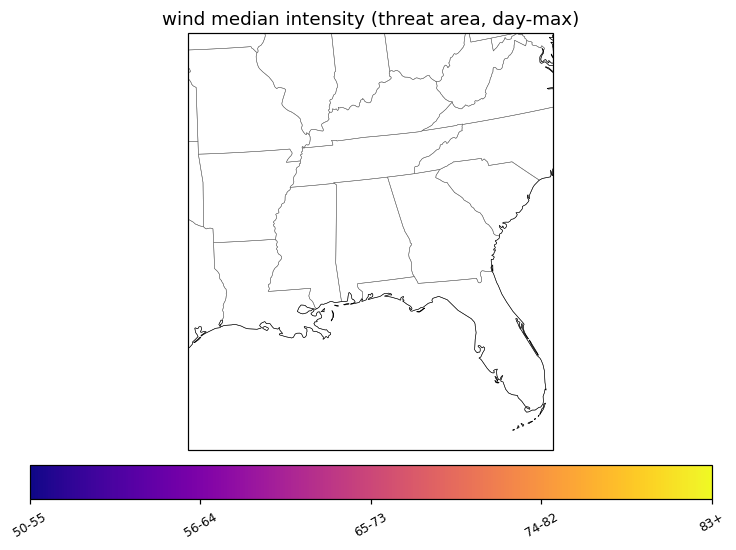

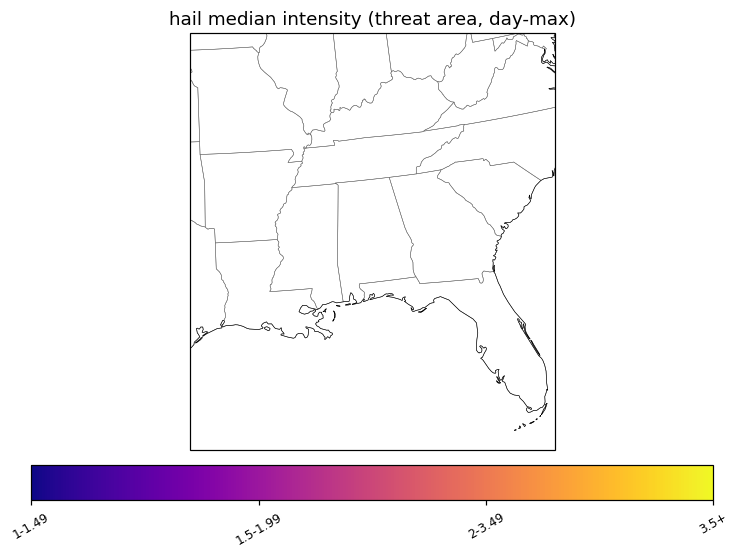

In [6]:
if preds:
    from IPython.display import Image, display
    # cumulative daily CATEGORICAL across ALL hazards (SPC-style Day-1 categorical)
    combined = summary.combined_categorical(preds)
    plots.plot_categorical(combined['category'], 'all', 'cumulative daily categorical (all hazards)', '/tmp/_day.png')
    display(Image('/tmp/_day.png'))
    # day-MAX median conditional-intensity bin for EACH hazard: per-hour
    # median bin, then the element-wise max over hours (strongest median
    # intensity reached anywhere that day). -1 = no mass; masked below.
    for h in C.HAZARDS:
        meds = np.stack([summary.median_intensity_bin(np.nan_to_num(preds[f][f'dist_{h}'])) for f in FXX], axis=0)
        med = meds.max(axis=0)
        daymax_h = summary.day_max({f: preds[f][f'p_{h}'] for f in FXX})
        med = np.where(daymax_h >= C.SPC_PROB_LEVELS[h][0], med, -1)  # threat area only
        plots.plot_intensity(med, h, f'{h} median intensity (threat area, day-max)', f'/tmp/_int_{h}.png')
        display(Image(f'/tmp/_int_{h}.png'))

## Forecast vs observed reports — overlay on the day-max probability

0 tor reports in valid window 2026-06-18 13Z -> 2026-06-19 06Z


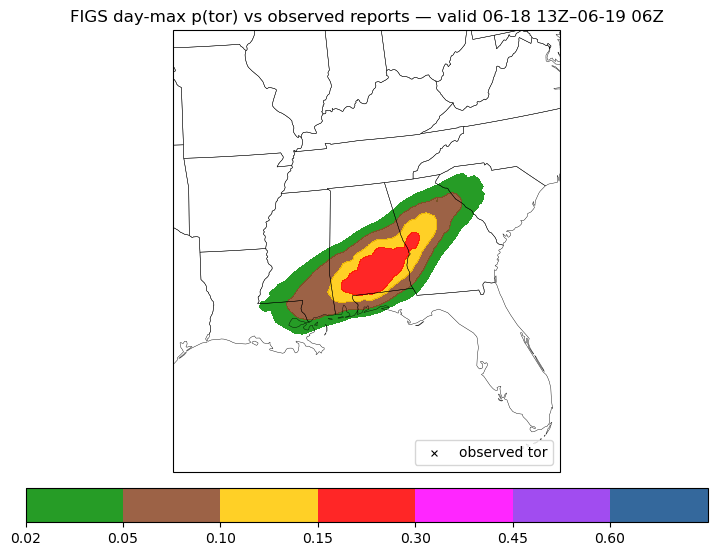

In [7]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
from figs.data.grid import figs_xy, lcc_forward, figs_latlon
day = RUN.replace(hour=0)  # convective-day label / SPC archive date
# Observed reports over the FORECAST VALID WINDOW (RUN+min..max FXX). An evening
# event spills past 00Z into the next UTC day, so fetch every UTC day it spans
# and filter to the window — a 00Z-00Z calendar fetch would miss those reports.
v0 = RUN + timedelta(hours=min(FXX)); v1 = RUN + timedelta(hours=max(FXX))
udays = sorted({v0.replace(hour=0,minute=0,second=0,microsecond=0),
                v1.replace(hour=0,minute=0,second=0,microsecond=0)})
rep_all = pd.concat([reports.reports_for_day(d) for d in udays], ignore_index=True)
rep_all = rep_all[(rep_all.time >= v0) & (rep_all.time <= v1)]
rep = rep_all[rep_all.hazard == HAZARD].copy()
print(len(rep), HAZARD, 'reports in valid window', f'{v0:%Y-%m-%d %HZ}', '->', f'{v1:%Y-%m-%d %HZ}')
lat, lon = figs_latlon()
daymax = summary.day_max({f: preds[f][f'p_{HAZARD}'] for f in FXX}) if preds else None
levels = list(C.SPC_PROB_LEVELS[HAZARD]) + [1.0]
fig = plt.figure(figsize=(11,7)); ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5))
ax.add_feature(cfeature.STATES, lw=0.3)
if MAP_EXTENT: ax.set_extent(MAP_EXTENT)
if daymax is not None:
    cf = ax.contourf(lon, lat, daymax, levels=levels, colors=plots.PROB_COLORS[HAZARD],
                     transform=ccrs.PlateCarree(), alpha=0.85, extend='neither')
    plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.03, shrink=0.8, ticks=C.SPC_PROB_LEVELS[HAZARD])
ax.scatter(rep.lon, rep.lat, s=18, c='black', marker='x', lw=0.8, transform=ccrs.PlateCarree(), label=f'observed {HAZARD}')
ax.set_title(f'FIGS day-max p({HAZARD}) vs observed reports — valid {v0:%m-%d %HZ}–{v1:%m-%d %HZ}'); ax.legend(loc='lower right'); plt.show()

### Capture: what fraction of observed reports fell inside each probability contour?

In [8]:
if preds is not None and len(rep):
    xc, yc = figs_xy(); x, y = lcc_forward(rep.lon.values, rep.lat.values)
    ix = np.round((x-xc[0])/(xc[1]-xc[0])).astype(int); iy = np.round((y-yc[0])/(yc[1]-yc[0])).astype(int)
    ok = (ix>=0)&(ix<len(xc))&(iy>=0)&(iy<len(yc))
    pvals = daymax[iy[ok], ix[ok]]
    print(f'{ok.sum()} in-domain reports | median forecast prob at report sites = {np.median(pvals):.3f}')
    for thr in C.SPC_PROB_LEVELS[HAZARD]:
        print(f'  captured at >= {int(thr*100):>2d}%: {100*(pvals>=thr).mean():5.1f}% of reports')
    # crude reliability for the day: report frequency vs forecast prob bin
    from figs.model.calibrate import reliability
    # (skipped here; see 02_training_progress for full reliability)

### Observed vs predicted conditional intensity

In [9]:
if preds is not None and len(rep):
    from figs.data.labels import intensity_bin
    labels = C.INTENSITY_BINS[HAZARD]['labels']; nb = len(labels)
    # observed intensity histogram (EF for tor; exclude EFU=-1)
    vals = rep.ef.values if HAZARD=='tor' else rep.magnitude.values
    obs = np.zeros(nb)
    for v in vals:
        b = intensity_bin(HAZARD, v)
        if b>=0: obs[b]+=1
    obs = obs/obs.sum() if obs.sum() else obs
    # predicted mean conditional distribution over the threat area (p>=5%)
    dist_day = np.nanmean([np.nan_to_num(preds[f][f'dist_{HAZARD}']) for f in FXX], axis=0)  # (nb,ny,nx)
    mask = daymax >= 0.05
    pred = dist_day[:, mask].mean(axis=1) if mask.any() else np.full(nb, np.nan)
    pred = pred/pred.sum()
    xpos = np.arange(nb); w=0.4
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(xpos-w/2, obs, w, label='observed'); ax.bar(xpos+w/2, pred, w, label='predicted (threat area)')
    ax.set_xticks(xpos); ax.set_xticklabels(labels); ax.set_ylabel('frequency'); ax.legend()
    ax.set_title(f'{HAZARD} conditional intensity: observed vs predicted'); plt.show()

## 6-panel: FIGS prob+CIG vs SPC outlooks (tornado / wind / hail)

Top row = FIGS day-max probability (SPC colors) with significant (CIG≥2) hatching;
bottom row = the **actual SPC Day-1 probabilistic outlook contours**, pulled as
vectors from the IEM GIS archive and drawn on the same projection (significant-
severe area hatched). The issuance closest to RUN is used.

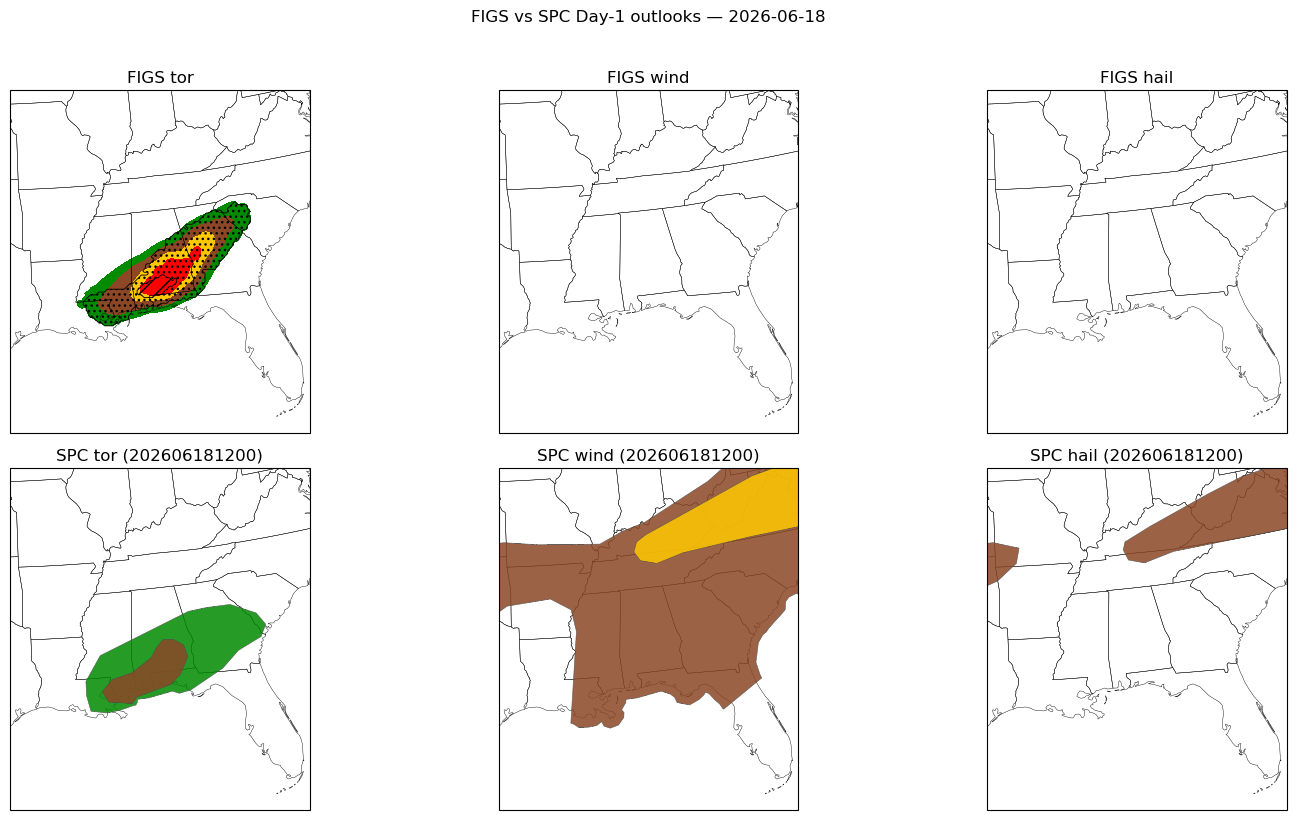

In [10]:
import cartopy.crs as ccrs, cartopy.feature as cfeature
from figs.products import cig as cigmod, spc
lat, lon = figs_latlon()
# actual SPC outlook contours from IEM (vector), selected to the run's issuance
spc_gdf = None
try:
    spc_gdf = spc.select_issuance(spc.fetch_spc_outlooks(RUN, day=1), RUN)
except Exception as e:
    print('SPC outlook fetch failed:', e)
spc_iss = (sorted(spc_gdf['ISSUE'].unique())[0] if spc_gdf is not None and len(spc_gdf) else 'n/a')
proj = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5)
fig = plt.figure(figsize=(16,8))
for j, h in enumerate(['tor','wind','hail']):
    ax = fig.add_subplot(2, 3, j+1, projection=proj)
    ax.add_feature(cfeature.STATES, lw=0.3)
    if MAP_EXTENT: ax.set_extent(MAP_EXTENT)
    if preds:
        dmax = summary.day_max({f: preds[f][f'p_{h}'] for f in FXX})
        lv = list(C.SPC_PROB_LEVELS[h]) + [1.0]
        ax.contourf(lon, lat, dmax, levels=lv, colors=plots.PROB_COLORS[h], transform=ccrs.PlateCarree(), extend='neither')
        # CIG derived HOUR-BY-HOUR (per-hour conditional dist), then maxed over
        # hours — matches summary.cumulative_categorical. Averaging the dist first
        # would dilute the upper tail and understate peak severity.
        cigmax = np.stack([cigmod.derive_cig_category(h, np.nan_to_num(preds[f][f'dist_{h}'])) for f in FXX], axis=0).max(axis=0)
        cigcat = np.where(dmax >= C.SPC_PROB_LEVELS[h][0], cigmax, 0)
        plots.overlay_cig(ax, lon, lat, cigcat)  # CIG1 dots / CIG2 diag / CIG3 cross, masked to prob area
    ax.set_title(f'FIGS {h}')
    ax2 = fig.add_subplot(2, 3, j+4, projection=proj)
    ax2.add_feature(cfeature.STATES, lw=0.3)
    if MAP_EXTENT: ax2.set_extent(MAP_EXTENT)
    spc.plot_spc_outlook(ax2, spc_gdf, h, plots.PROB_COLORS[h])  # filled by prob threshold + SIGN hatch
    ax2.set_title(f'SPC {h} ({spc_iss})')
fig.suptitle(f'FIGS vs SPC Day-1 outlooks — {day:%Y-%m-%d}', y=1.02); plt.tight_layout(); plt.show()

## Inspect a saved prediction netCDF

In [11]:
# import xarray as xr
# ds = xr.open_dataset(f'../Data/products/figs_{RUN:%Y%m%d_%HZ}.nc'); ds